# Exploratory Data Analysis (EDA)

In this notebook, we will perform a comprehensive analysis of the banking data to understand the underlying patterns and factors contributing to customer churn.

### Objectives
* **Data Structure:** Understand the types of features and check for quality issues.
* **Statistical Summary:** Gain insights into the distribution of numerical and categorical variables.
* **Correlation Analysis:** Identify relationships between features and the target variable.
* **Visual Insights:** Use visualizations to detect outliers, trends, and key drivers of churn.

--- 
**Methodology & Tools:**
This analysis utilizes custom utility classes (`DataAnalyzer` and `DataVisualizer`) imported from the project's `src` module.

---
**Input Data:** The analysis is based on the **training set** (`data/processed/train.csv`) to avoid data leakage from the test set.


In [19]:
# import necessary libraries
import os
import sys
import pandas as pd 

# Add the project root directory to sys.path to allow importing from 'src'
sys.path.append(os.path.abspath(os.path.join('..')))

# Import custom classes for data analysis and visualization
from src.utils.eda import DataAnalyzer
from src.utils.visualizer import DataVisualizer

In [20]:
# Load the processed training data
train_data = pd.read_csv('../data/processed/train.csv')

In [21]:
# Initialize the custom classes for data analysis and visualization
analyzer = DataAnalyzer(train_data)
visualizer = DataVisualizer(train_data, target_col='Exited')

In [22]:
analyzer.show_all()


#################### GENERAL OVERVIEW ####################
Veri Seti Boyutu: (9000, 18)

#################### DUPLICATES ####################

Tekrar eden satır sayısı: 0

#################### FEATURE TYPES ####################
Numerical Features (14): ['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Point Earned']
Categorical Features (4): ['Surname', 'Geography', 'Gender', 'Card Type']

#################### MISSING VALUES ####################
Veri setinde hiç eksik değer yok.

#################### COLUMN SUMMARY ####################
                      Dtype  N_Unique  Missing_Rate (%)
RowNumber             int64      9000               0.0
Satisfaction Score    int64         5               0.0
Complain              int64         2               0.0
Exited                int64         2               0.0
IsActiveMember        int64         2       

### Dataset Overview and Statistical Summary

The dataset structure has been examined, and key statistical insights are summarized below based on the analyzer output:

**1. Structural Analysis (Structure & Quality):**
* **Dimensions:** The dataset consists of **9,000 rows** and **18 variables**.
* **Data Quality:** There are no **missing values** or **duplicates**.
* **Feature Types:** The dataset contains **14 numerical** and 4 categorical features.

**2. Key Insights:**
* **Target Variable (Exited):** The churn rate is approximately **20.5%**. This indicates a **Class Imbalance**, which must be addressed during the modeling phase.
* **Financial Status (Balance):** At least **25%** of customers have a zero account balance (indicated by the 25th percentile value of 0.00).
* **Demographics:** The average customer age is **39**. The age range spans from 18 to 92.
* **Geographical Distribution:** The dominant geography is **France**, accounting for 4,509 customers (approximately **50%** of the data).

**3. Anomalies:**
* **Complain:** The mean value (**20.6%**) is almost identical to the *Exited* target variable (**20.5%**). This suggests a potential data leakage or a 1-to-1 relationship that needs investigation.

Numerical Features (14): ['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Point Earned']
Categorical Features (4): ['Surname', 'Geography', 'Gender', 'Card Type']


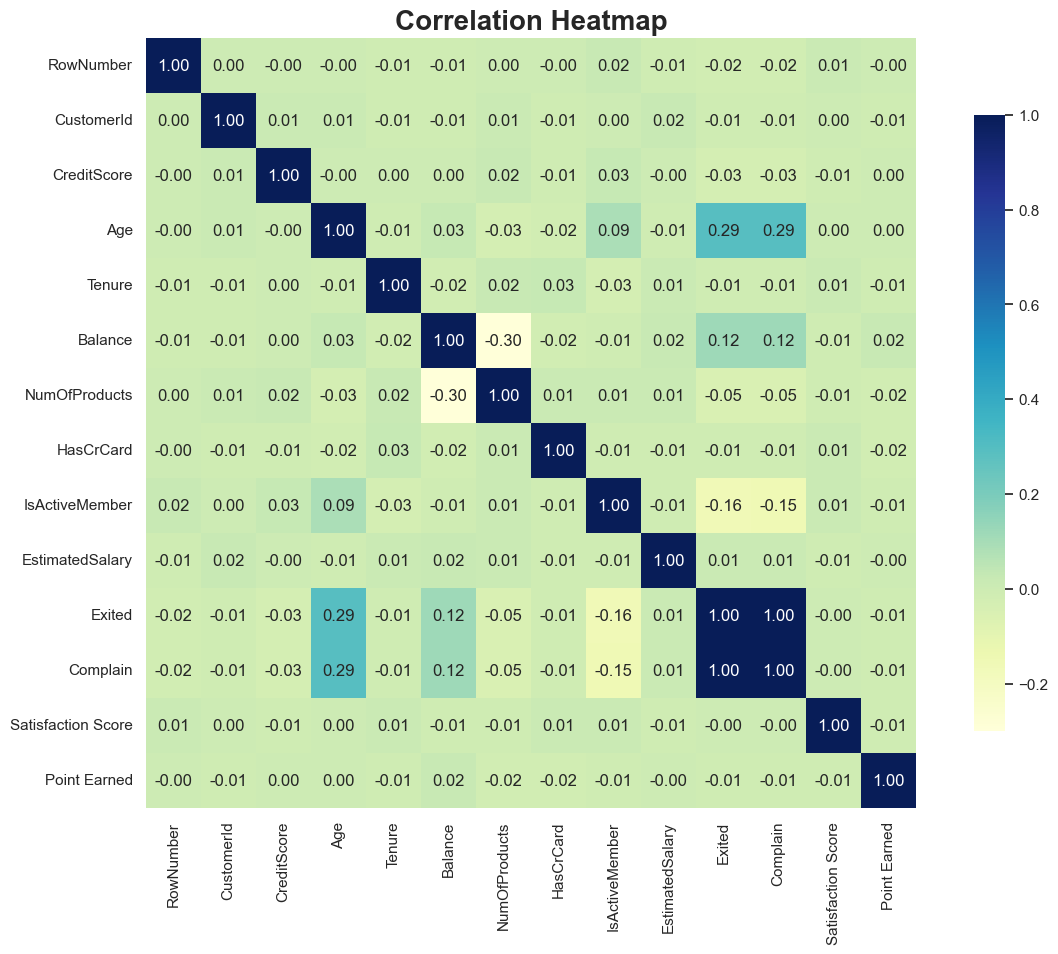

In [23]:
visualizer.plot_correlation_heatmap()

### Correlation Analysis and Insights

The relationships between features and the target variable (Exited), as well as inter-feature correlations, have been examined using the heatmap.

**1. Observations:**
*   **Age:** Has a positive correlation of **0.29** with the target variable *Exited*. This indicates that older customers have a higher tendency to churn.
*   **Balance & NumOfProducts:** There is a negative correlation of **-0.30** between these two features. As the balance increases, the number of products tends to decrease (or vice versa).
*   **IsActiveMember:** Active members are less likely to churn, indicated by a negative correlation of **-0.16**.

**2. Critical Finding:**
*   **Complain & Exited:** A **perfect correlation of 1.00** exists between these two variables. This implies that every customer who complained has churned. Such a high correlation poses a significant risk of *Data Leakage*, which would compromise the model's ability to generalize.

**Decision Taken:**
To ensure model consistency and prevent "Overfitting," the **'Complain' feature will be removed from the dataset**, as it carries identical information to the target variable.

In [24]:
visualizer = DataVisualizer(train_data, target_col='Exited')

Numerical Features (14): ['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Point Earned']
Categorical Features (4): ['Surname', 'Geography', 'Gender', 'Card Type']


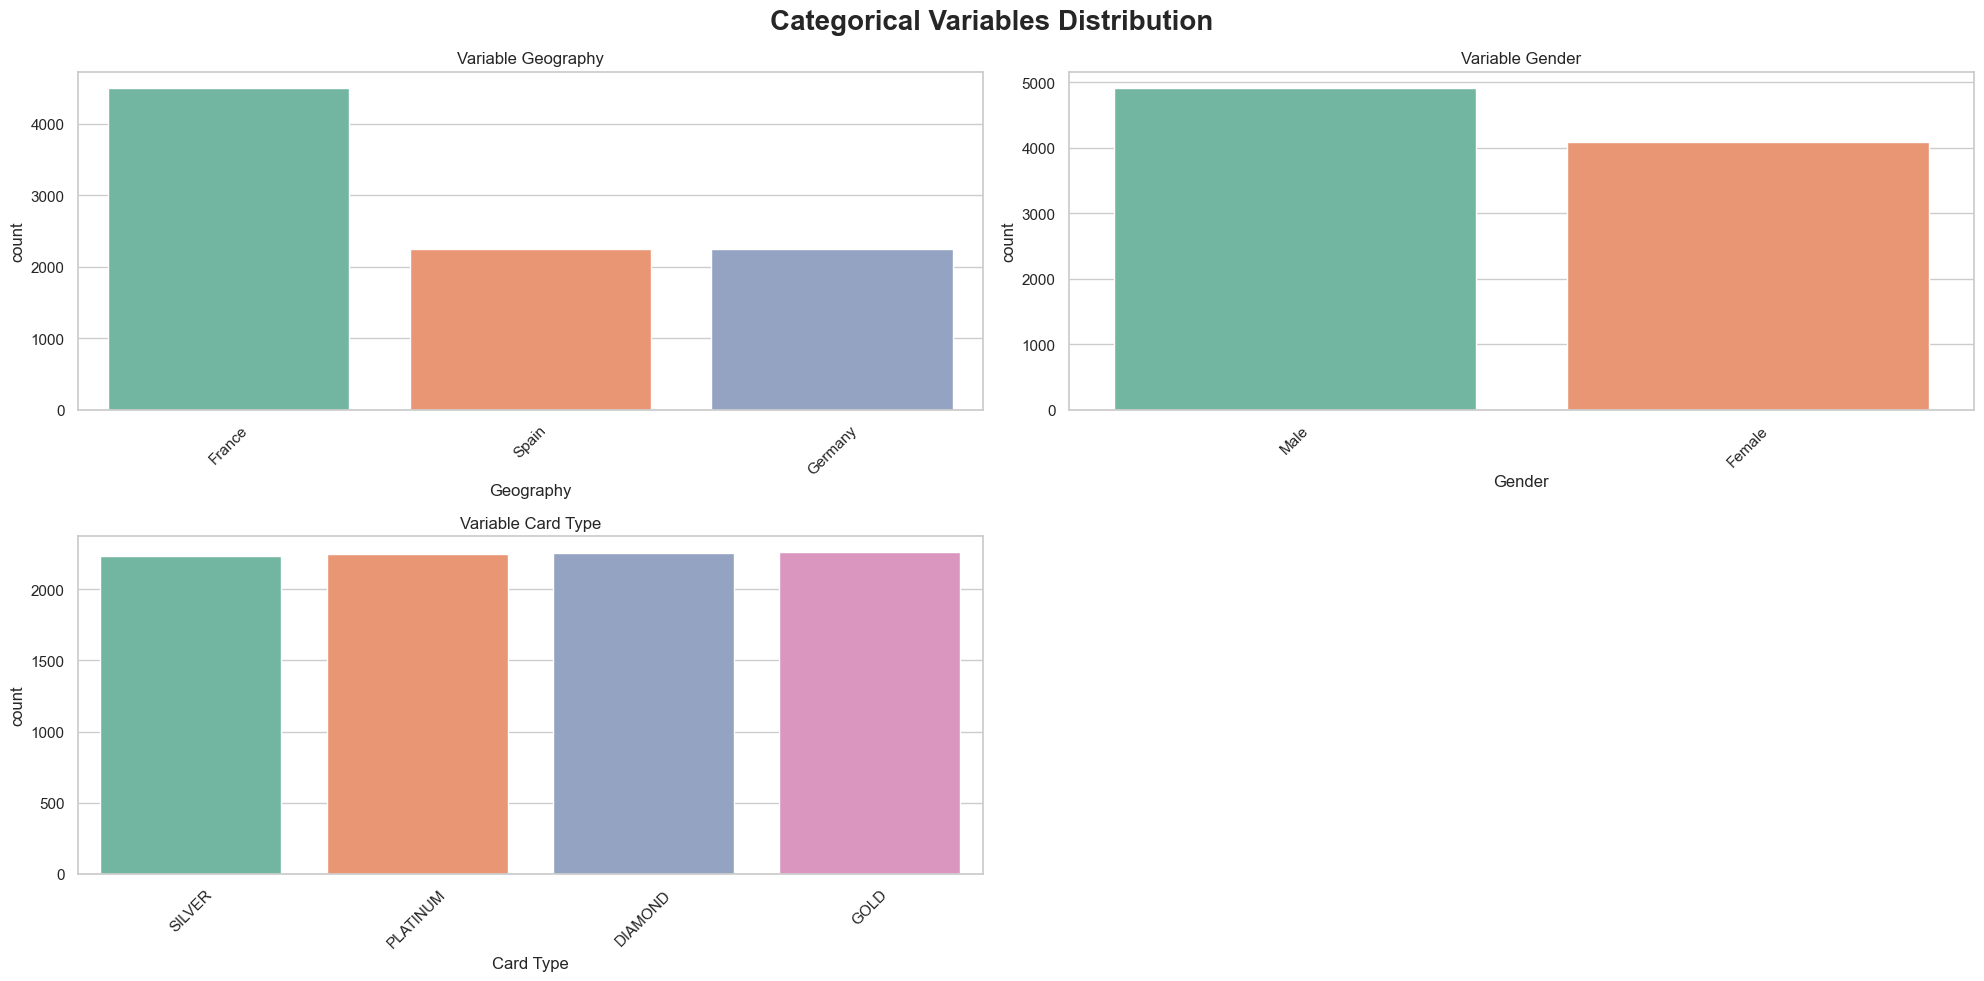

In [25]:
visualizer.plot_categorical_distributions()

Numerical Features (14): ['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Point Earned']
Categorical Features (4): ['Surname', 'Geography', 'Gender', 'Card Type']


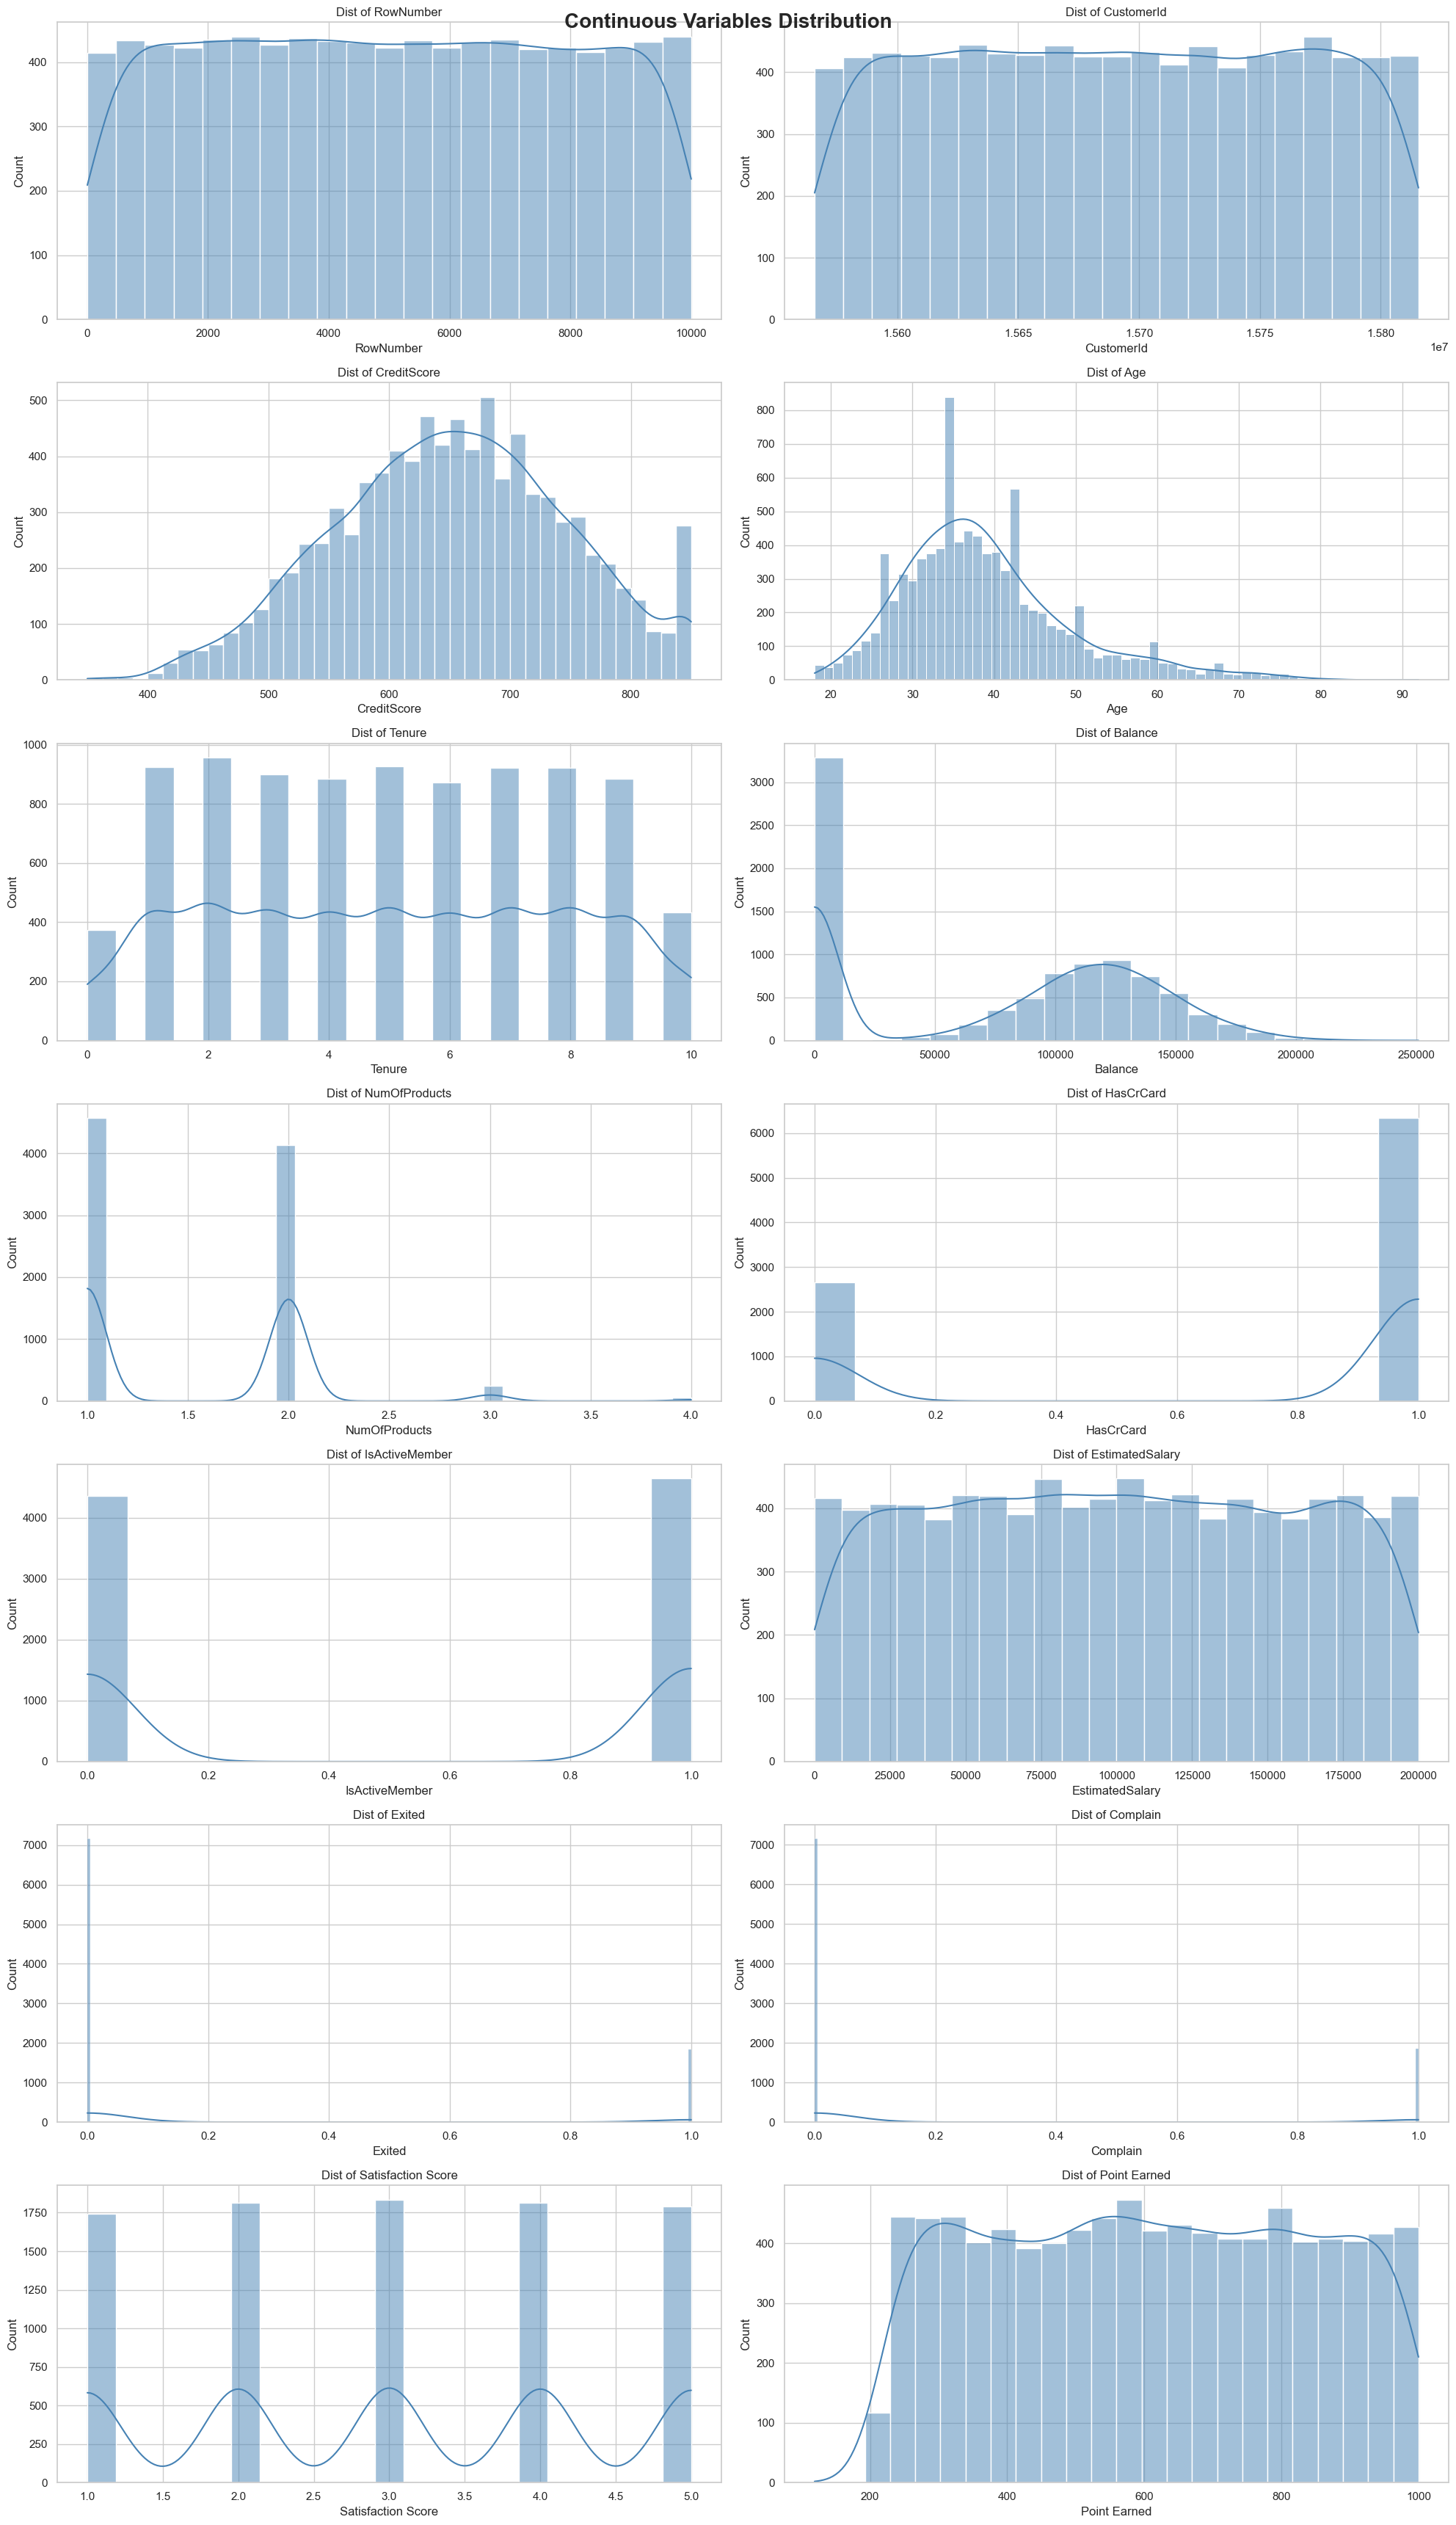

In [26]:
visualizer.plot_numerical_distributions()

### Continuous Variable Analysis and Action Plan

Upon examining the distributions of the remaining variables after data cleaning, the following strategic decisions have been made:

**1. Distribution Anomalies:**
*   **Balance:** The distribution shows a significant spike at the "0" value. To better capture this pattern for the model, a new feature named `HasBalance` (binary: 0 or 1) will be derived.

**2. Class Imbalance:**
*   **Target (Exited):** The churn rate is low (~20%), as confirmed by the distribution plot. To avoid the "Accuracy Paradox," evaluation metrics such as **F1-Score** or **ROC-AUC** will be prioritized over accuracy.

**3. Uniform Distributions:**
*   **EstimatedSalary:** The distribution is nearly uniform, meaning customers are equally distributed across all salary ranges. This suggests no specific salary segment dominates the dataset.

Numerical Features (14): ['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Point Earned']
Categorical Features (4): ['Surname', 'Geography', 'Gender', 'Card Type']


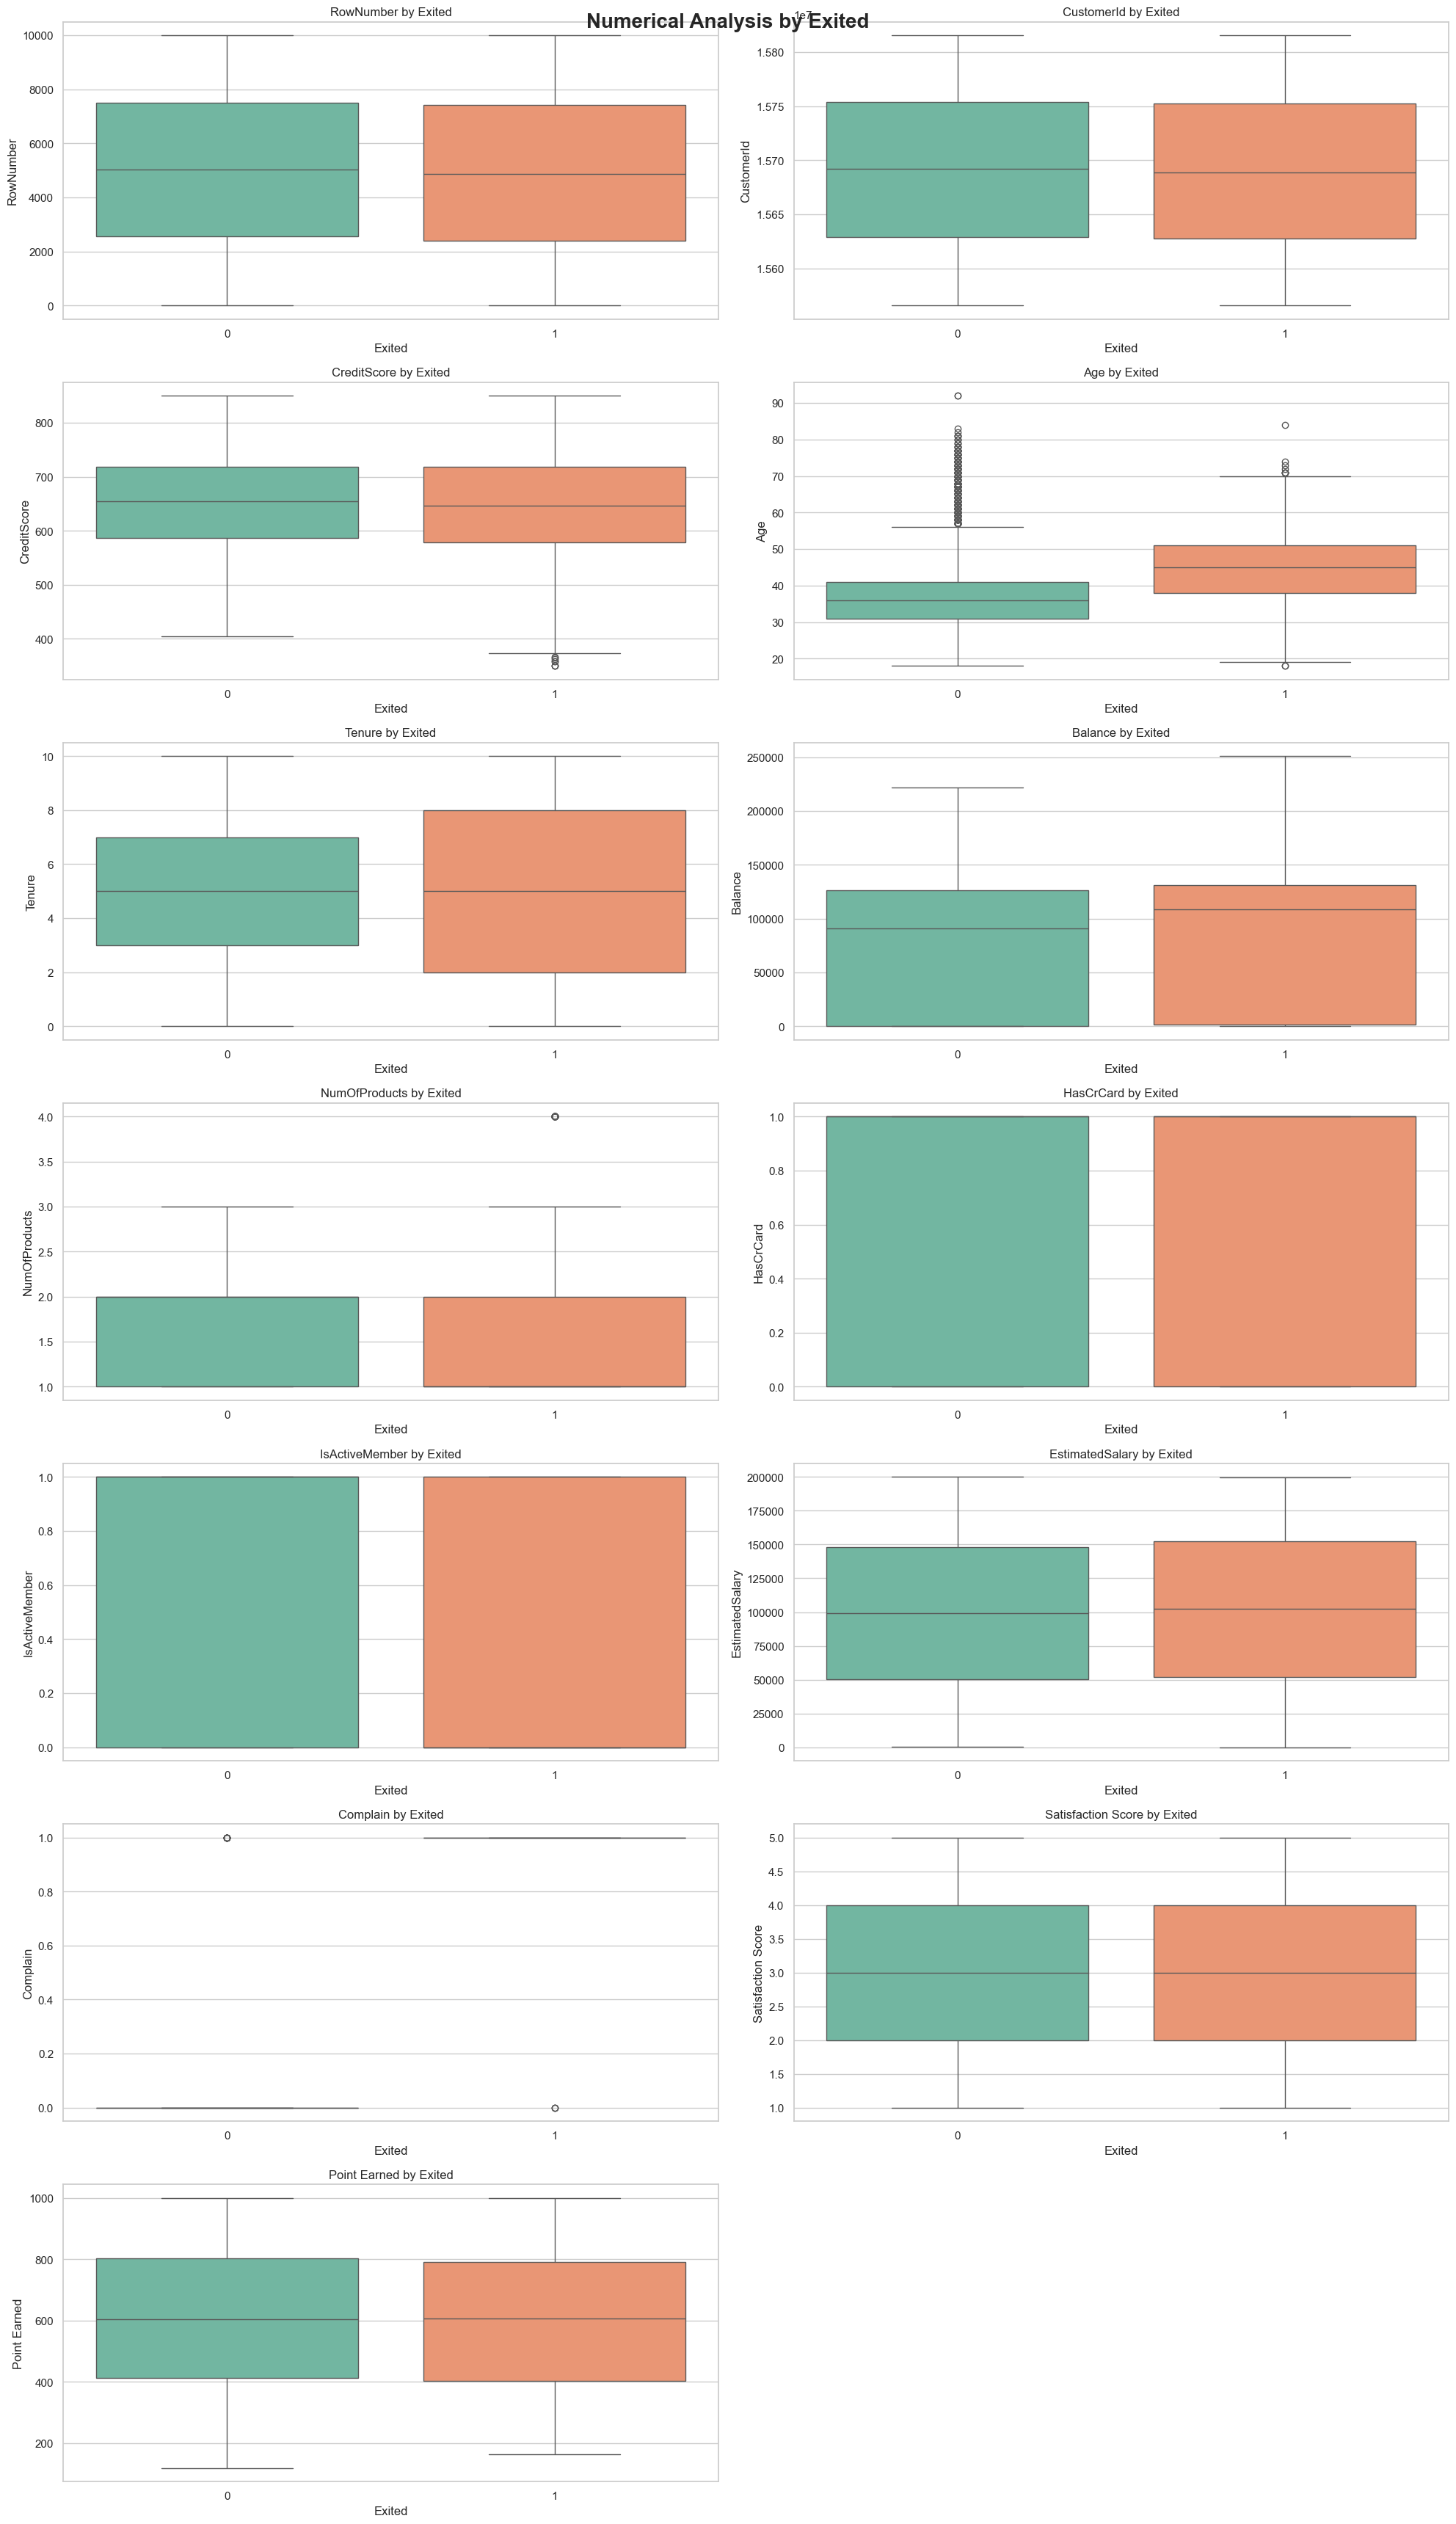

In [27]:
visualizer.plot_numerical_by_target()

Numerical Features (14): ['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Point Earned']
Categorical Features (4): ['Surname', 'Geography', 'Gender', 'Card Type']


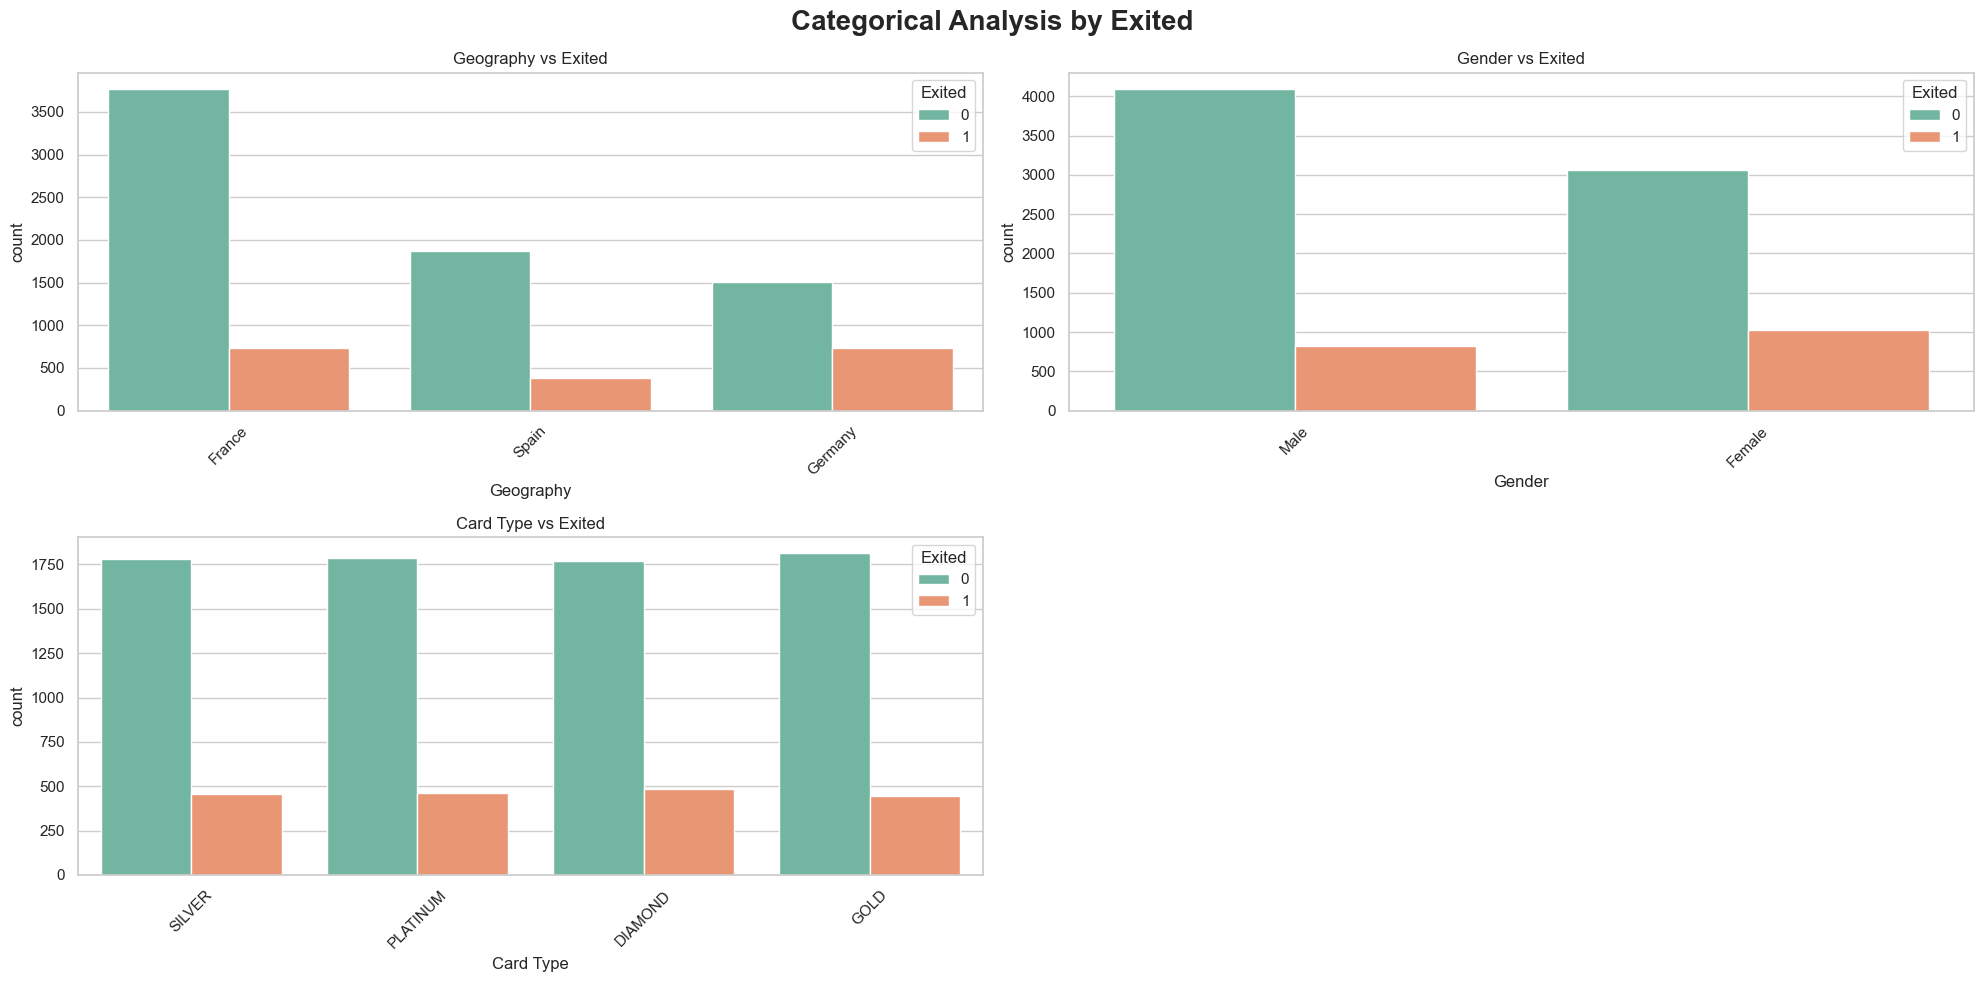

In [28]:
visualizer.plot_categorical_by_target()

Numerical Features (14): ['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Point Earned']
Categorical Features (4): ['Surname', 'Geography', 'Gender', 'Card Type']


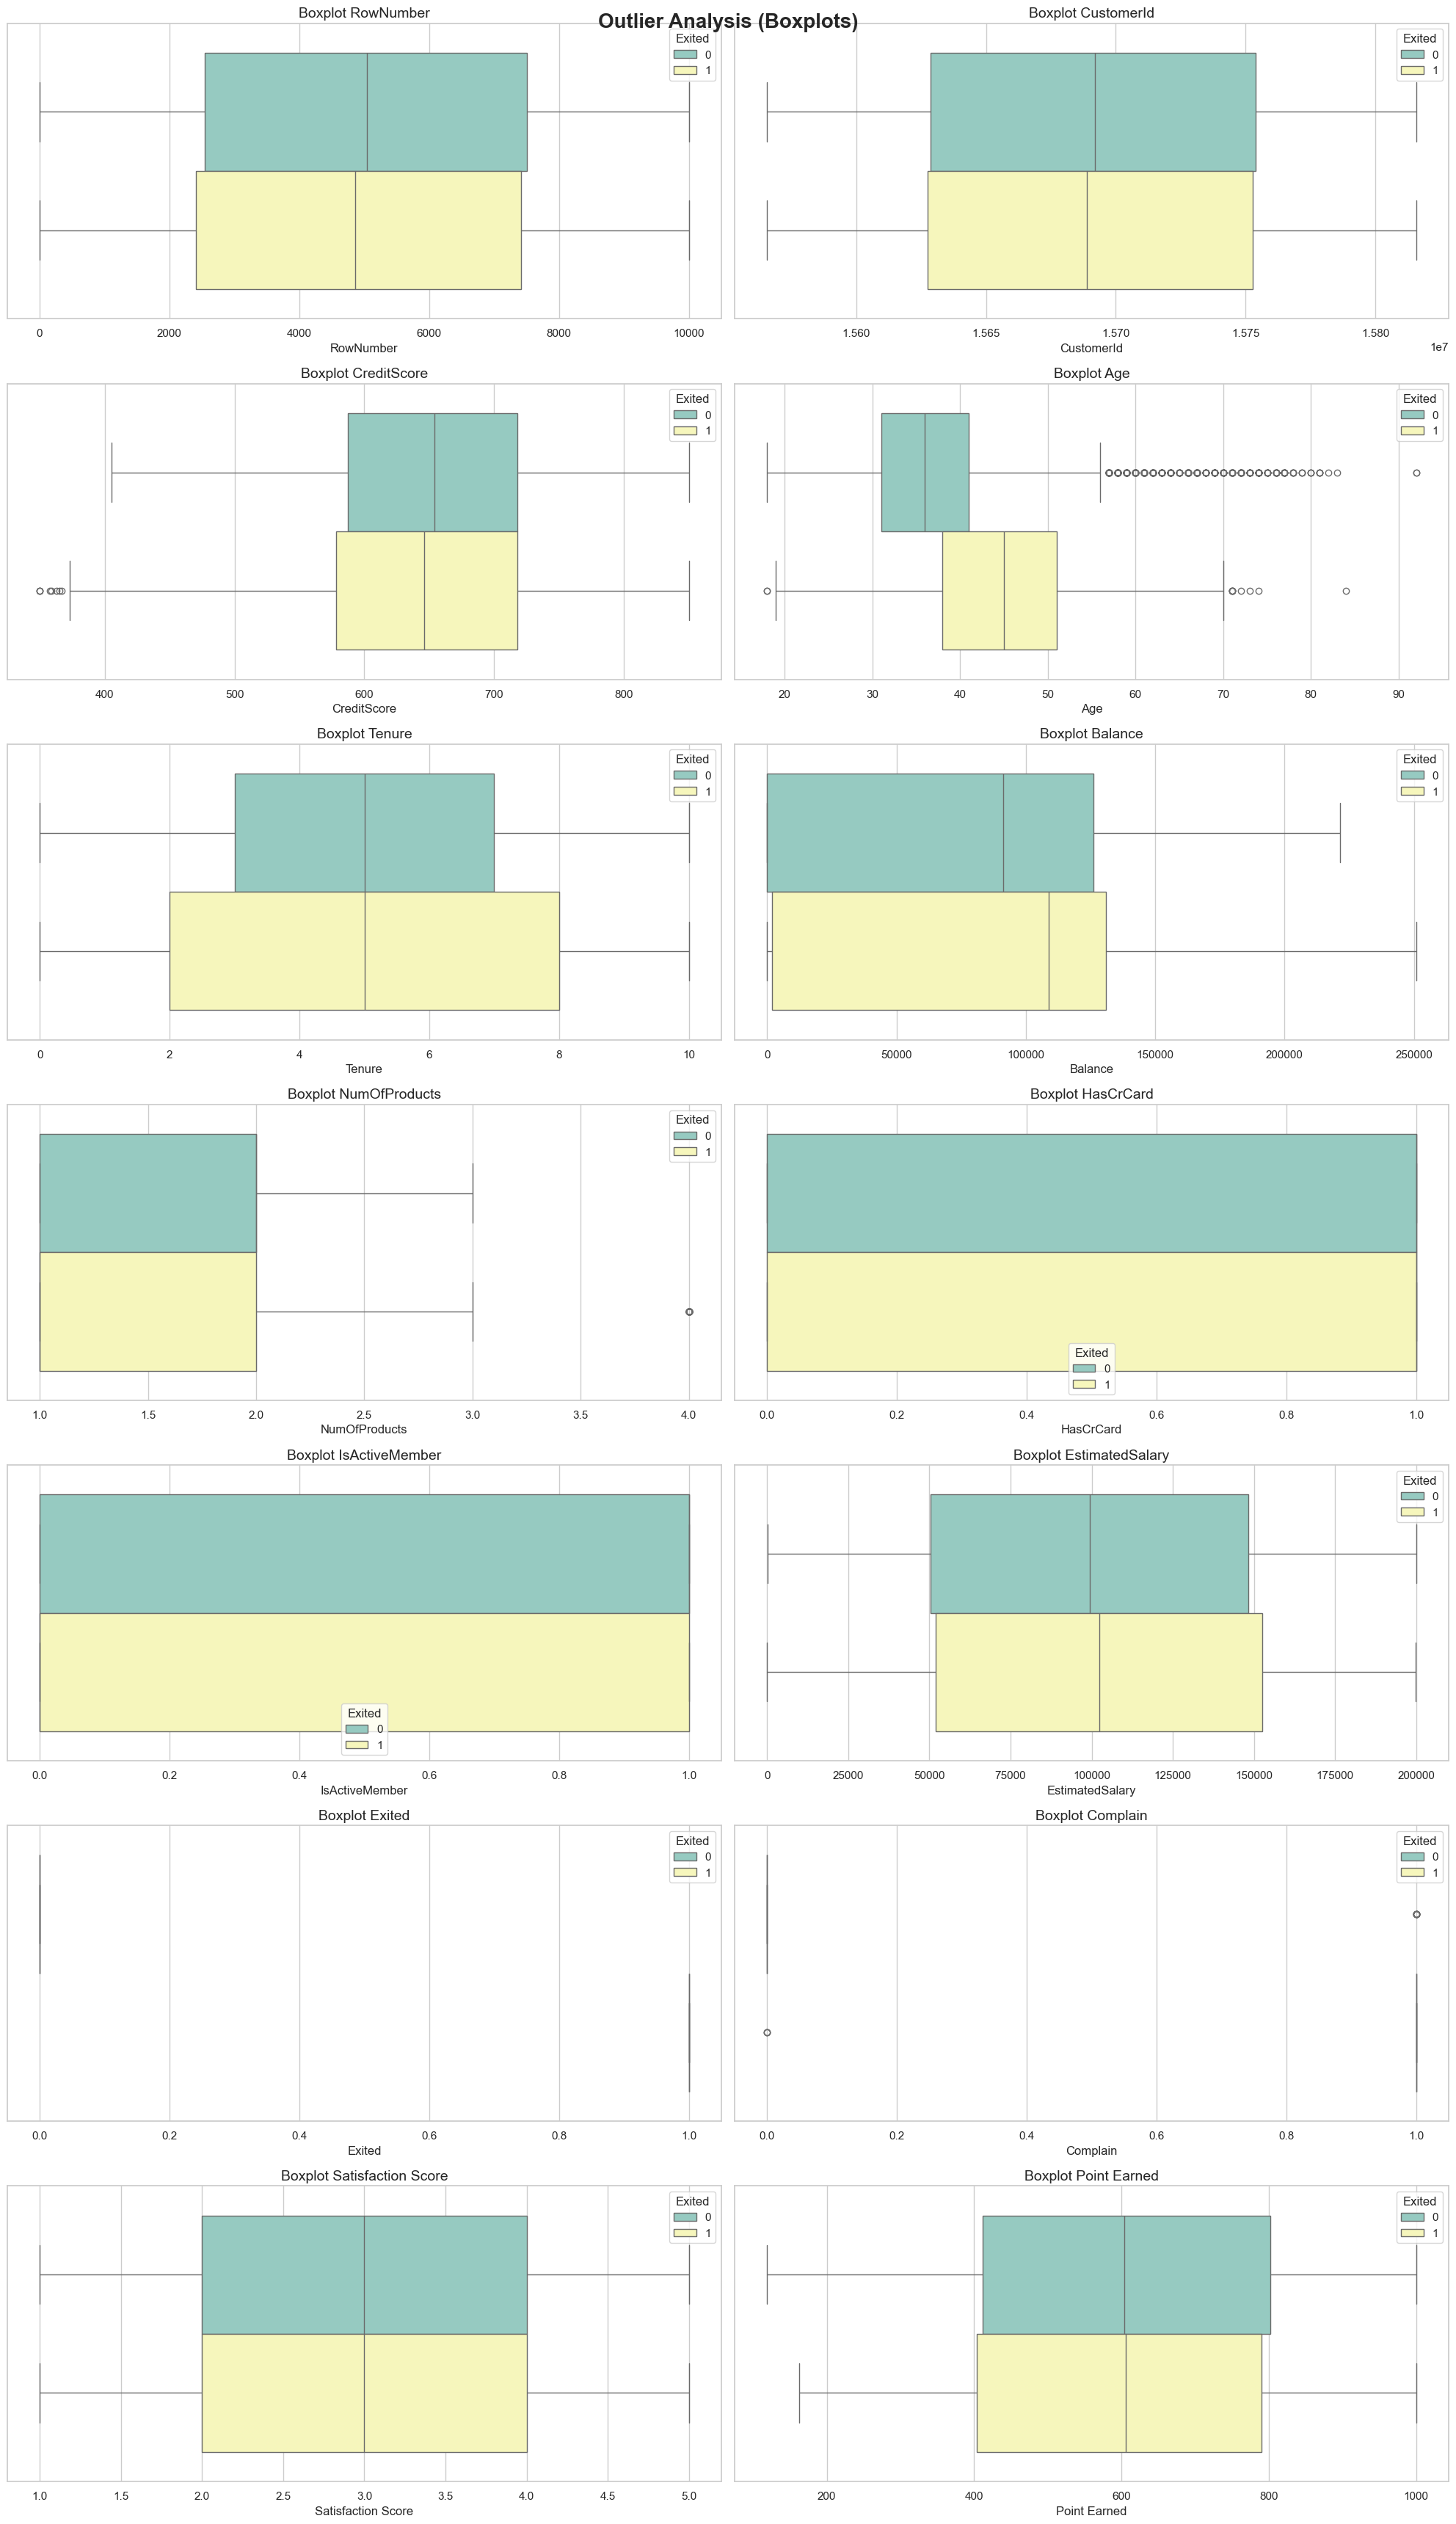

In [29]:
visualizer.plot_outliers()

### Outlier and Relationship Analysis

An analysis of variable behaviors with respect to the target variable (Exited) yields the following insights:

1.  **Age Factor:** Customers who churned have a significantly higher average age compared to those who stayed. This suggests age is a strong predictor of churn.
2.  **Balance Risk:** Customers with higher account balances show a greater tendency to churn. This indicates the bank is losing customers from the *wealthy segment*.
3.  **Outliers:** In the `CreditScore` variable, low-score outliers are concentrated within the "Retained" (0) group.
4.  **Ineffective Variables:** The boxplots for `EstimatedSalary` and `Tenure` show nearly identical distributions for both classes. These variables are expected to have weak predictive power on their own.